# Corridor Profile Tests — Cellular Hybrid vs Survey-Only Matrices (GEH per link, shape D)

Tests the corridor demand profiles of the **cellular hybrid** (`Output/ths2017/study_taz/hybrid_taz_trips.csv`, the primary fusion product) against the **survey-only** matrices of `THS_2017_two_mode_matrix.ipynb`, on the same footing:

- **same vintage** — both at 2018 (the survey-only set before its move to 2022);
- **same mode content** — the hybrid carries all modes, so its walk / other layer is removed with the survey's own mode split per superzone pair (fallback: origin superzone, then region); total = car + transit, transit = bus + taxi-type + rail;
- **same construction** — the 18-area line sequence and the link-assignment rule of the earlier profiles.

Two statistics, both judged against the survey's **day 1 vs day 2** profiles (the same construction on the two survey days, rebuilt here):

1. **GEH per link and direction** on hourly flows (3-hour flow / 3) — the statistic made for link flows; share of links and of flow within GEH 5 and 10.
2. **Shape descriptor D** — each profile normalised to its share of link-trips along the line, cumulated from Tirat Carmel to Nazareth; D is the largest gap between two cumulative curves and says where along the line the shapes diverge most. It is a descriptor, not a test with a p-value.

A KS test proper is not applied: a profile is a fixed-order curve of 17 dependent, weighted values, not a sample from a distribution.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/ths2017/tests'; os.makedirs(OUT, exist_ok=True)
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6, axis='y'); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=11)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

# zone systems
keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER']).astype({'TAZ_NUMBER': int, 'SZ_NEW': int}); kd = kn.drop_duplicates('TAZ_NUMBER')
TAZ = np.array(sorted(kd['TAZ_NUMBER'])); N = len(TAZ); taz_pos = {t: i for i, t in enumerate(TAZ)}
sz_of = kd.set_index('TAZ_NUMBER')['SZ_NEW'].reindex(TAZ).values; SZ = sorted(set(sz_of)); sz_pos = {z: i for i, z in enumerate(SZ)}
M_sz = np.zeros((N, len(SZ))); M_sz[np.arange(N), [sz_pos[z] for z in sz_of]] = 1
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx'); area_of = sub_key.set_index('TAZ')['AggAreaCode']; AREA = sorted(area_of.unique())
M_area = np.zeros((N, len(AREA)))
for i, t in enumerate(TAZ):
    if t in area_of.index: M_area[i, AREA.index(area_of[t])] = 1
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode'); names = legend['AggAreaName']
ref = pd.read_csv('Output/transit/corridor_link_flows_2022.csv'); SEQ = list(ref['from_code']) + [int(ref['to_code'].iloc[-1])]
def load_sq(path):
    m = pd.read_csv(path, index_col=0); m.index = m.index.astype(float).astype(int); m.columns = m.columns.astype(float).astype(int)
    return m.reindex(index=TAZ, columns=TAZ).fillna(0).values
to_area = lambda X: pd.DataFrame(M_area.T @ X @ M_area, index=AREA, columns=AREA)

## 1. Matrices at 2018 with matching mode content

In [2]:
# survey-only 2018 components (population / employment allocation)
car = load_sq('Output/ths2017/two_mode/car_taz.csv'); bus = load_sq('Output/ths2017/two_mode/bus_survey_taz.csv')
taxi = load_sq('Output/ths2017/two_mode/taxi_survey_taz.csv'); rail = load_sq('Output/ths2017/two_mode/rail_survey_taz.csv')
bus_cal = load_sq('Output/ths2017/two_mode/bus_calibrated_taz.csv')
S_transit, S_total = bus + taxi + rail, car + bus + taxi + rail
S_transit_cal = bus_cal + taxi + rail
# survey OTHER layer and the mode split per superzone pair (from the survey's own components)
other = load_sq('Output/ths2017/study_taz/matrix_avg_OTHER_taz.csv')     # survey OTHER, pipeline allocation (same trips, same total)
sz_all = M_sz.T @ (S_total + other) @ M_sz; sz_tr = M_sz.T @ S_transit @ M_sz; sz_oth = M_sz.T @ other @ M_sz
def share_pair(num, den):
    s = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
    row = np.divide(num.sum(axis=1), den.sum(axis=1), out=np.full(len(SZ), num.sum() / den.sum()), where=den.sum(axis=1) > 0)
    return np.where(np.isnan(s), row[:, None], s)
sh_oth, sh_tr = share_pair(sz_oth, sz_all), share_pair(sz_tr, sz_all)
col = np.array([sz_pos[z] for z in sz_of])
H_all = load_sq('Output/ths2017/study_taz/hybrid_taz_trips.csv')
H_total = H_all * (1 - sh_oth)[col][:, col]          # car + transit
H_transit = H_all * sh_tr[col][:, col]
print(f"survey-only 2018: car + transit {S_total.sum():,.0f} (transit {S_transit.sum():,.0f}); other modes {other.sum():,.0f}")
print(f"cellular hybrid 2018: all modes {H_all.sum():,.0f} → car + transit {H_total.sum():,.0f} (transit {H_transit.sum():,.0f}) after removing the survey's other-mode share per superzone pair "
      f"({sh_oth.min():.2f}–{sh_oth.max():.2f}, trip-weighted {(sz_oth.sum() / sz_all.sum()):.2f})")

survey-only 2018: car + transit 1,423,047 (transit 139,458); other modes 645,111
cellular hybrid 2018: all modes 2,068,158 → car + transit 1,428,673 (transit 140,387) after removing the survey's other-mode share per superzone pair (0.00–1.00, trip-weighted 0.31)


### Survey day 1 / day 2 (noise reference), same allocation

In [3]:
df = pd.read_excel('Input/trips_ths_2017.xlsx')
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy(); g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h']); trips = trips[trips['trip_dep_h'].isin([6, 7, 8])].copy()
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636'); map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips['o1250'] = trips['origin'].map(map_2636_1250); trips['d1250'] = trips['actTaz'].map(map_2636_1250)
children = kd.groupby('TAZ_1270')['TAZ_NUMBER'].apply(list); north_1250 = sorted(children.index); z_idx = {z: i for i, z in enumerate(north_1250)}
tm = trips[trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)].copy(); tm['oi'] = tm['o1250'].map(z_idx); tm['di'] = tm['d1250'].map(z_idx)
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID').reindex(TAZ)
pop, emp = zon['POPULATION'].fillna(0).values, zon['EMPL_TOT'].fillna(0).values
def alloc(primary, secondary):
    S = np.zeros((len(north_1250), N))
    for z, kids in children.items():
        idx = [taz_pos[t] for t in kids]
        for v in (primary[idx], secondary[idx], np.ones(len(idx))):
            if v.sum() > 0: S[z_idx[z], idx] = v / v.sum(); break
    return S
S_o, S_d = alloc(pop, emp), alloc(emp, pop)
CT = {'car': [10, 11], 'bus': [3, 4], 'taxi': [5, 8], 'rail': [7]}
def day_mat(day, codes):
    sub = tm[(tm['SurveyDay'] == day) & tm['mainmode'].isin(codes)]
    M = np.zeros((len(north_1250),) * 2); np.add.at(M, (sub['oi'].values, sub['di'].values), sub['new_wf'].values); return S_o.T @ M @ S_d
D = {day: {k: day_mat(day, v) for k, v in CT.items()} for day in (1, 2)}
D_total = {day: sum(D[day].values()) for day in (1, 2)}; D_transit = {day: D[day]['bus'] + D[day]['taxi'] + D[day]['rail'] for day in (1, 2)}
assert abs((D_total[1] + D_total[2]).sum() / 2 - S_total.sum()) < 1, "day average must reproduce the survey-only matrix"
print(f"day 1 / day 2 car + transit: {D_total[1].sum():,.0f} / {D_total[2].sum():,.0f}; transit {D_transit[1].sum():,.0f} / {D_transit[2].sum():,.0f}")

day 1 / day 2 car + transit: 1,439,364 / 1,406,730; transit 141,566 / 137,349


## 2. Profiles and tests

In [4]:
def link_flows(m):
    sub = m.reindex(index=SEQ, columns=SEQ).fillna(0).values; n = len(SEQ)
    f, b = np.zeros(n - 1), np.zeros(n - 1)
    for i in range(n):
        for j in range(n):
            if i < j: f[i:j] += sub[i, j]
            elif i > j: b[j:i] += sub[i, j]
    return {'1→23': f, '23→1': b}
links = [f'{names[a]} – {names[b]}' for a, b in zip(SEQ[:-1], SEQ[1:])]
SETS = {'total': {'hybrid': H_total, 'survey-only': S_total, 'survey day 1': D_total[1], 'survey day 2': D_total[2]},
        'transit': {'hybrid': H_transit, 'survey-only': S_transit, 'survey-only (bus calibrated)': S_transit_cal, 'survey day 1': D_transit[1], 'survey day 2': D_transit[2]}}
PROF = {k: {n: link_flows(to_area(v)) for n, v in V.items()} for k, V in SETS.items()}

def geh(m, c):
    m, c = np.asarray(m) / 3, np.asarray(c) / 3; s = m + c
    return np.where(s > 0, np.sqrt(2 * (m - c) ** 2 / np.where(s == 0, 1, s)), 0)
def shape_D(a, b):
    ca, cb = np.cumsum(a) / a.sum(), np.cumsum(b) / b.sum(); i = int(np.argmax(np.abs(ca - cb)))
    return float(abs(ca - cb)[i]), links[i], float((ca - cb)[i])

rows, link_rows = [], []
for k in SETS:
    for a, b in [('hybrid', 'survey-only'), ('survey day 1', 'survey day 2')] + ([('hybrid', 'survey-only (bus calibrated)')] if k == 'transit' else []):
        for d in ['1→23', '23→1']:
            pa, pb = PROF[k][a][d], PROF[k][b][d]; G = geh(pa, pb); w = (pa + pb) / 2
            Dv, where, sg = shape_D(pa, pb)
            rows.append({'profile': k, 'pair': f'{a} vs {b}', 'direction': d, 'A link-trips': pa.sum(), 'B link-trips': pb.sum(), 'ratio A/B': pa.sum() / pb.sum(),
                         'A peak link': links[int(np.argmax(pa))], 'B peak link': links[int(np.argmax(pb))],
                         'links GEH<5': float((G < 5).mean()), 'links GEH<10': float((G < 10).mean()), 'flow GEH<5': float(w[G < 5].sum() / w.sum()), 'flow GEH<10': float(w[G < 10].sum() / w.sum()),
                         'max GEH': float(G.max()), 'max GEH link': links[int(np.argmax(G))], 'shape D': Dv, 'D at link': where, 'D signed (A−B)': sg, 'correlation': float(np.corrcoef(pa, pb)[0, 1])})
            for i, l in enumerate(links):
                link_rows.append({'profile': k, 'pair': f'{a} vs {b}', 'direction': d, 'link': l, 'A': pa[i], 'B': pb[i], 'ratio': pa[i] / pb[i] if pb[i] > 0 else np.nan, 'GEH': G[i]})
res = pd.DataFrame(rows); res.to_csv(f'{OUT}/corridor_profile_hybrid_vs_survey_summary.csv', index=False, float_format='%.4f')
pd.DataFrame(link_rows).to_csv(f'{OUT}/corridor_profile_hybrid_vs_survey_links.csv', index=False, float_format='%.3f')
res.set_index(['profile', 'pair', 'direction'])[['ratio A/B', 'links GEH<5', 'links GEH<10', 'flow GEH<5', 'flow GEH<10', 'max GEH', 'max GEH link', 'shape D', 'D at link', 'correlation']].round(3)

ratio A/B  \
profile pair                                   direction              
total   hybrid vs survey-only                  1→23           1.047   
                                               23→1           1.130   
        survey day 1 vs survey day 2           1→23           0.999   
                                               23→1           1.016   
transit hybrid vs survey-only                  1→23           0.655   
                                               23→1           0.884   
        survey day 1 vs survey day 2           1→23           1.065   
                                               23→1           0.694   
        hybrid vs survey-only (bus calibrated) 1→23           0.579   
                                               23→1           0.562   

                                                          links GEH<5  \
profile pair                                   direction                
total   hybrid vs survey-only                  1→23             0.706   
                                               23→1             0.412   
        survey day 1 vs survey day 2           1→23             0.941   
                                               23→1             0.235   
transit hybrid vs survey-only                  1→23             0.471   
                                               23→1             0.765   
        survey day 1 vs survey day 2           1→23             0.882   
                                               23→1             0.294   
        hybrid vs survey-only (bus calibrated) 1→23             0.235   
                                               23→1             0.059   

                                                          links GEH<10  \
profile pair                                   direction                 
total   hybrid vs survey-only                  1→23              0.765   
                                               23→1              0.588   
        survey day 1 vs survey day 2           1→23              1.000   
                                               23→1              0.765   
transit hybrid vs survey-only                  1→23              0.882   
                                               23→1              1.000   
        survey day 1 vs survey day 2           1→23              1.000   
                                               23→1              0.706   
        hybrid vs survey-only (bus calibrated) 1→23              0.706   
                                               23→1              0.529   

                                                          flow GEH<5  \
profile pair                                   direction               
total   hybrid vs survey-only                  1→23            0.570   
                                               23→1            0.307   
        survey day 1 vs survey day 2           1→23            0.996   
                                               23→1            0.252   
transit hybrid vs survey-only                  1→23            0.225   
                                               23→1            0.748   
        survey day 1 vs survey day 2           1→23            0.941   
                                               23→1            0.385   
        hybrid vs survey-only (bus calibrated) 1→23            0.007   
                                               23→1            0.085   

                                                          flow GEH<10  \
profile pair                                   direction                
total   hybrid vs survey-only                  1→23             0.683   
                                               23→1             0.538   
        survey day 1 vs survey day 2           1→23             1.000   
                                               23→1             0.832   
transit hybrid vs survey-only                  1→23             0.751   
                                               23→1            

In [5]:
lk = pd.DataFrame(link_rows)
for k in SETS:
    print(f"\n{k.upper()} — hybrid vs survey-only, GEH per link (hourly flows):")
    t = lk[(lk['profile'] == k) & (lk['pair'] == 'hybrid vs survey-only')].pivot(index='link', columns='direction', values=['A', 'B', 'GEH']).reindex(links)
    t.columns = [f'{v} {d}' for v, d in t.columns]
    print(t[['A 1→23', 'B 1→23', 'GEH 1→23', 'A 23→1', 'B 23→1', 'GEH 23→1']].rename(columns=lambda c: c.replace('A ', 'hybrid ').replace('B ', 'survey ')).round(1).to_string())


TOTAL — hybrid vs survey-only, GEH per link (hourly flows):
                                         hybrid 1→23  survey 1→23  GEH 1→23  hybrid 23→1  survey 23→1  GEH 23→1
link                                                                                                           
TiratCarmel – Matam                           4381.9       3167.7      11.4       1897.2       1566.8       4.6
Matam – Neot Peres                            3812.7       2762.3      10.6       3146.2       3006.5       1.5
Neot Peres – Neve David                       3973.7       2489.8      15.1       4775.7       3414.5      12.3
Neve David – Ein Hayam                        4818.0       4345.4       4.0       6392.6       3517.8      23.6
Ein Hayam – Bat Galim                         4748.4       6376.2      12.6       6418.0       2955.8      29.2
Bat Galim – Kiryat Eliezer                    5220.7       6075.3       6.6       6693.4       5690.4       7.4
Kiryat Eliezer – Hamoshava                 

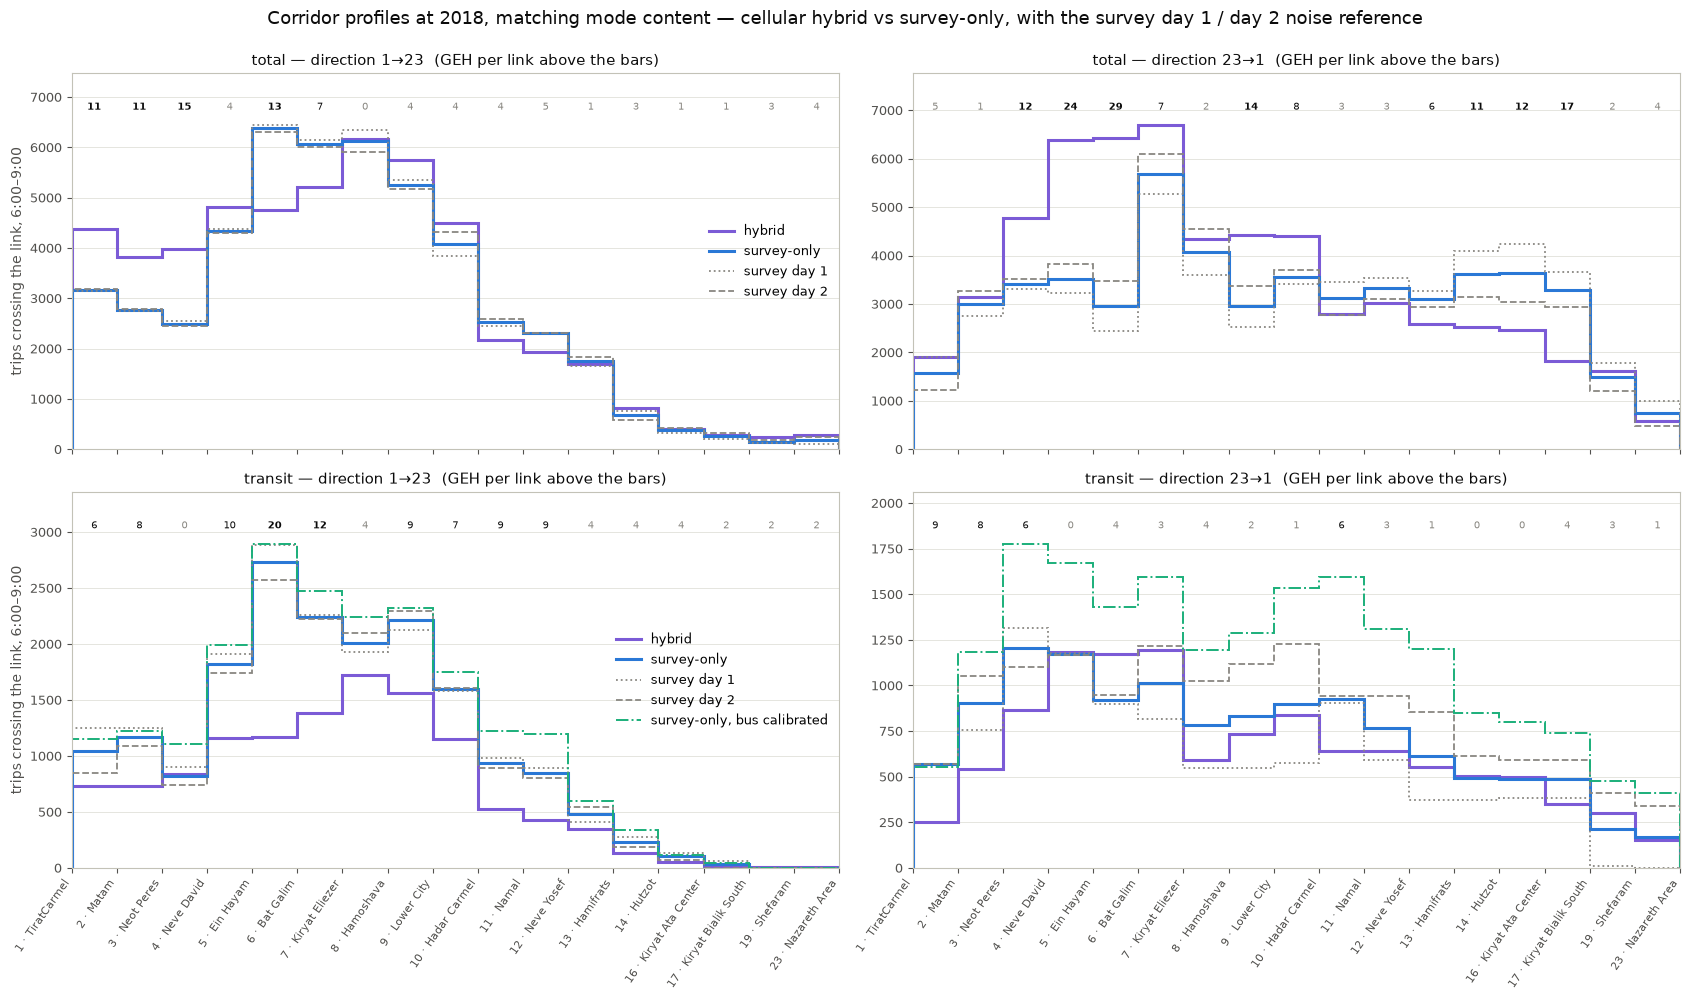

In [6]:
x = np.arange(len(SEQ))
fig, axes = plt.subplots(2, 2, figsize=(17, 10), facecolor='white', sharex=True)
for r_, k in enumerate(SETS):
    for c_, d in enumerate(['1→23', '23→1']):
        ax = axes[r_, c_]
        for n_, color, ls, lw in [('hybrid', PURPLE, '-', 2.2), ('survey-only', BLUE, '-', 2.2), ('survey day 1', MUTED, ':', 1.3), ('survey day 2', MUTED, '--', 1.3)]:
            ax.stairs(PROF[k][n_][d], x, color=color, linestyle=ls, linewidth=lw, label=n_)
        if k == 'transit': ax.stairs(PROF[k]['survey-only (bus calibrated)'][d], x, color=AQUA, linestyle='-.', linewidth=1.4, label='survey-only, bus calibrated')
        G = geh(PROF[k]['hybrid'][d], PROF[k]['survey-only'][d]); top = max(v[d].max() for v in PROF[k].values())
        for i, gv in enumerate(G):
            ax.text(i + 0.5, top * 1.04, f'{gv:.0f}', ha='center', va='bottom', fontsize=7.5, color=INK if gv >= 5 else MUTED, fontweight='bold' if gv >= 10 else 'normal')
        ax.set_ylim(0, top * 1.16); ax.set_xlim(0, len(SEQ) - 1)
        style_ax(ax, f'{k} — direction {d}  (GEH per link above the bars)', None, 'trips crossing the link, 6:00–9:00' if c_ == 0 else None)
        if c_ == 0: ax.legend(frameon=False, fontsize=9, loc='center right')
for ax in axes[1]: ax.set_xticks(x); ax.set_xticklabels([f'{a} · {names[a]}' for a in SEQ], rotation=55, ha='right', fontsize=8, color=INK2)
fig.suptitle('Corridor profiles at 2018, matching mode content — cellular hybrid vs survey-only, with the survey day 1 / day 2 noise reference', color=INK, fontsize=13, y=0.995)
plt.tight_layout(); fig.savefig('Output/figures/corridor_profile_hybrid_vs_survey.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

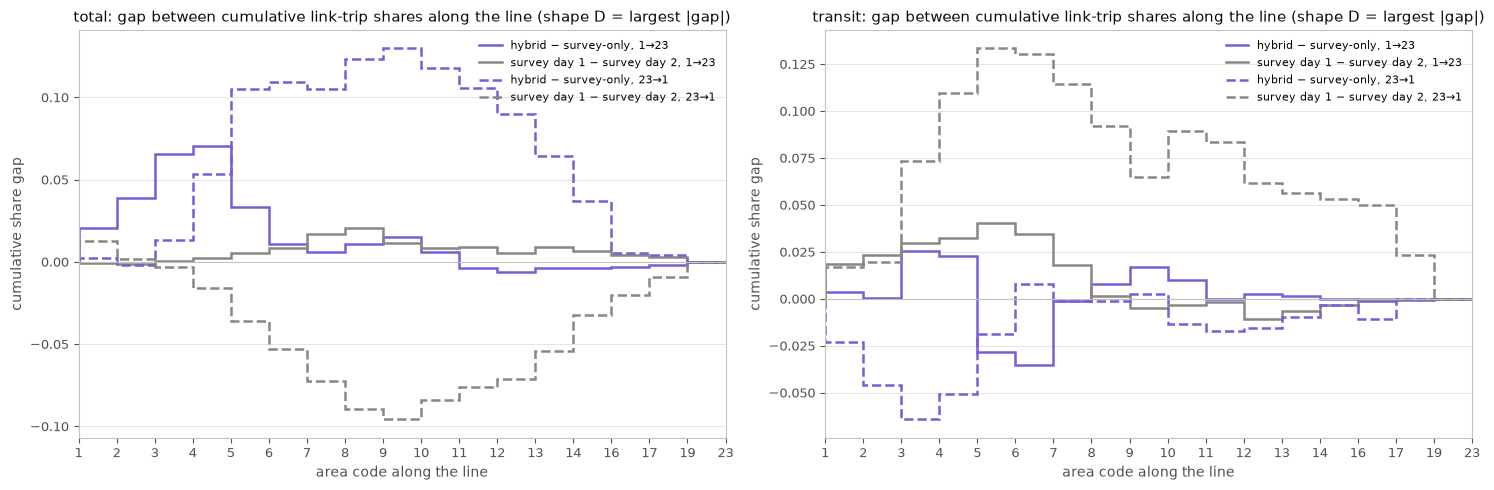

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')
for ax, k in zip(axes, SETS):
    for d, ls in [('1→23', '-'), ('23→1', '--')]:
        for a, b, color in [('hybrid', 'survey-only', PURPLE), ('survey day 1', 'survey day 2', MUTED)]:
            pa, pb = PROF[k][a][d], PROF[k][b][d]
            ax.stairs(np.cumsum(pa) / pa.sum() - np.cumsum(pb) / pb.sum(), x, color=color, linestyle=ls, linewidth=1.8, label=f'{a} − {b}, {d}')
    ax.axhline(0, color=AXIS, linewidth=0.8); ax.set_xlim(0, len(SEQ) - 1)
    ax.set_xticks(x); ax.set_xticklabels([f'{a}' for a in SEQ], fontsize=8, color=INK2)
    style_ax(ax, f'{k}: gap between cumulative link-trip shares along the line (shape D = largest |gap|)', 'area code along the line', 'cumulative share gap')
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); fig.savefig('Output/figures/corridor_profile_hybrid_vs_survey_shape.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## Notes

- **What is being compared.** The cellular hybrid's corridor cells rest on cellular structure below the superzone (corrected by survey factors); the survey-only matrix's corridor cells rest on the survey's 1,250-zone pattern split by population / employment. Both carry the survey's superzone-level pattern and volumes, so the profiles test the sub-superzone allocation more than anything else.
- **Mode matching.** The hybrid's walk / other layer is removed with the survey's own other-mode share per superzone pair; that share is itself survey-based, so the hybrid "car + transit" is an approximation, exact at superzone level.
- **Reading GEH here.** Link flows in the corridor are 1,000–7,000 trips per three hours, i.e. 300–2,300 an hour, where GEH 5 corresponds to roughly ±10–20 %. The day 1 vs day 2 rows show how much of that band the survey's own sampling noise consumes.